## Step 0 - Problem Statement and Proposed Solution

Pemantauan kualitas air permukaan secara kontinu saat ini sangat bergantung pada jaringan sensor Internet of Things (IoT). Meskipun mampu menghasilkan data dalam volume besar dengan resolusi waktu yang tinggi, sistem sensor IoT di lingkungan akuatik sangat rentan terhadap kegagalan teknis, seperti biofouling (penumpukan lumut/bakteri pada probe sensor), kehabisan daya, atau kerusakan kalibrasi, yang menghasilkan pembacaan data yang tidak valid. Di sisi lain, perubahan ekstrem pada kualitas air juga dapat disebabkan oleh kejadian nyata, seperti pembuangan limbah ilegal atau badai hujan yang menyebabkan lonjakan kekeruhan (turbidity) secara drastis. Tantangan komputasional utama dalam ranah ini adalah membedakan antara "fluktuasi ekstrem alami" dan "anomali sesungguhnya" (baik akibat kerusakan sensor maupun pencemaran) di tengah triliunan titik data yang tidak memiliki label (unlabeled data).

Metode deteksi ambang batas statis (static thresholding) tradisional terbukti tidak memadai karena parameter kualitas air bersifat sangat dinamis, multivariat, dan memiliki dependensi temporal (deret waktu). Misalnya, penurunan kadar Oksigen Terlarut (DO) mungkin dianggap normal jika terjadi pada malam hari atau saat suhu air sedang tinggi, namun menjadi anomali kritis jika terjadi secara tiba-tiba tanpa korelasi dengan parameter lain. Oleh karena itu, diperlukan rekayasa fitur (feature engineering) yang mengekstrak konteks historis—seperti rata-rata pergerakan mingguan (rolling mean) dan selisih harian (time-step difference)—agar algoritma dapat memahami pola siklus alami sungai sebelum mencoba mencari keanehan di dalamnya.

Untuk mengatasi ketiadaan label anomali pada data historis, pendekatan Unsupervised Machine Learning seperti Local Outlier Factor (LOF) dan One-Class Support Vector Machine (OCSVM) menjadi solusi yang paling optimal. Namun, evaluasi kinerja model unsupervised seringkali bersifat subjektif. Oleh karena itu, simulasi injeksi anomali sintetik (synthetic anomaly injection) yang merepresentasikan kerusakan sensor (univariat) dan pencemaran (multivariat) mutlak diperlukan sebagai ground truth objektif untuk mengukur metrik F1-Score model pada saat pengujian.

Lebih lanjut, setiap algoritma unsupervised memiliki kelemahan bawaan (blind spots); algoritma berbasis kepadatan lokal (seperti LOF) mungkin unggul dalam mendeteksi lonjakan tiba-tiba, sementara algoritma berbasis batas (seperti OCSVM) lebih baik dalam melihat penyimpangan secara global. Untuk menekan tingginya angka False Positive yang sering menjangkiti sistem deteksi anomali tunggal, penerapan Heterogeneous Ensemble berbasis Majority Vote diusulkan sebagai strategi penggabungan keputusan. Pada akhirnya, kontribusi dari seluruh rekayasa komputasional ini harus divalidasi melalui studi ablasi (ablation study) guna membuktikan secara empiris bahwa ekstraksi fitur deret waktu secara signifikan meningkatkan kemampuan model dibandingkan jika hanya menggunakan data mentah sensor.

## Step 1 - Import Library

Pada tahap ini seluruh library yang dibutuhkan diimpor di satu tempat agar mudah ditelusuri. Library yang digunakan terdiri dari:
- **pandas, numpy**: manipulasi data tabular dan numerik.
- **matplotlib, seaborn, plotly**: visualisasi statis dan interaktif.
- **scikit-learn**: algoritma `LocalOutlierFactor`, `OneClassSVM`, `RobustScaler`, dan metrik evaluasi (`f1_score`, `classification_report`, `confusion_matrix`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    f1_score,
    classification_report,
    accuracy_score,
    confusion_matrix,
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Step 2 - Data Loading and Initial Inspection

Dataset yang digunakan berasal dari sensor sungai Clackamas River. Pada langkah ini dilakukan:
1. Pembacaan file CSV mentah.
2. Pemilihan kolom parameter kualitas air yang relevan dan mengganti namanya menjadi label yang lebih mudah dibaca.
3. Konversi kolom waktu ke `datetime` dan menjadikannya index.
4. Filter rentang data ke periode 10 tahun (2014–2023) untuk konsistensi analisis.

In [2]:
df_raw = pd.read_csv("../data/clackamas_river.csv")
print(f"Ukuran data mentah: {df_raw.shape}")

Ukuran data mentah: (6209, 34)


In [3]:
# Pemilihan dan penamaan ulang kolom yang relevan
rename_dict = {
    "00010_Mean":   "Temperature",
    "00300_Mean":   "Dissolved Oxygen",
    "00400_Median": "pH",
    "63680_Median": "Turbidity",
}

selected_columns = ['datetime'] + list(rename_dict.keys())
df = df_raw[selected_columns].copy()
df = df.rename(columns=rename_dict)
df.head()

,datetime,Temperature,Dissolved Oxygen,pH,Turbidity
0,2007-01-01 00:00:00+00:00,4.2,13.7,7.4,3.9
1,2007-01-02 00:00:00+00:00,5.3,13.3,7.4,3.7
2,2007-01-03 00:00:00+00:00,6.4,13.1,7.3,78.5
3,2007-01-04 00:00:00+00:00,6.2,13.2,7.2,61.0
4,2007-01-05 00:00:00+00:00,5.5,13.4,7.3,23.0


In [4]:
# Konversi kolom datetime ke tipe datetime
df['datetime'] = pd.to_datetime(df['datetime'], utc=True, errors='coerce')

baris_rusak = df['datetime'].isna().sum()
print(f"Jumlah baris dengan datetime rusak yang akan dibuang: {baris_rusak} baris")

df = df.dropna(subset=['datetime']).set_index('datetime')

Jumlah baris dengan datetime rusak yang akan dibuang: 217 baris


In [5]:
# Filter rentang waktu 2014 - 2023 (10 tahun)
df = df.loc['2014':'2023']
print("--- Info Data Setelah Filter 10 Tahun ---")
df.info()

--- Info Data Setelah Filter 10 Tahun ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3562 entries, 2014-01-01 00:00:00+00:00 to 2023-12-31 00:00:00+00:00
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Temperature       3560 non-null   float64
 1   Dissolved Oxygen  3541 non-null   float64
 2   pH                3522 non-null   float64
 3   Turbidity         3512 non-null   float64
dtypes: float64(4)
memory usage: 139.1 KB


## Step 3 - Exploratory Data Analysis (EDA)

EDA bertujuan untuk memahami karakteristik data sebelum pemodelan, antara lain:
- Statistik deskriptif (mean, std, min, max).
- Identifikasi hari yang hilang dari sensor (gap waktu).
- Visualisasi tren temporal untuk setiap parameter.
- Distribusi tiap parameter (histogram + boxplot).
- Hubungan antar parameter melalui matriks korelasi.

In [6]:
print("--- Statistik Deskriptif ---")
df.describe()

--- Statistik Deskriptif ---


,Temperature,Dissolved Oxygen,pH,Turbidity
count,3560.000000,3541.000000,3522.000000,3512.000000
mean,11.504775,11.134425,7.526917,2.579584
std,5.604703,1.414884,0.269678,4.771787
min,0.900000,8.200000,6.800000,0.100000
25%,6.700000,9.900000,7.300000,0.800000
50%,10.100000,11.400000,7.500000,1.400000
75%,16.200000,12.300000,7.700000,2.500000
max,23.900000,14.500000,8.400000,91.600000


### Step 3.A - Identifikasi Hari yang Hilang

Karena data deret waktu, perlu dipastikan apakah ada hari yang tidak memiliki record sensor. Hari yang hilang akan dimasukkan kembali sebagai baris kosong (`NaN`) melalui `reindex` agar tahap imputasi nanti bisa menanganinya.

In [7]:
full_date_range = pd.date_range(start='2014-01-01', end='2023-12-31', freq='D', tz='UTC')
missing_dates = full_date_range.difference(df.index)

print(f"Total hari yang hilang dari sensor: {len(missing_dates)} hari")
if len(missing_dates) > 0:
    print("Contoh 5 tanggal yang hilang:", [d.strftime('%Y-%m-%d') for d in missing_dates[:5]])

df = df.reindex(full_date_range)
df.index.name = 'datetime'
print(f"Total baris setelah reindex: {len(df)} baris")

Total hari yang hilang dari sensor: 90 hari
Contoh 5 tanggal yang hilang: ['2014-10-05', '2014-10-06', '2014-11-21', '2014-11-22', '2014-11-23']
Total baris setelah reindex: 3652 baris


In [8]:
print("--- Total Nilai Kosong (NaN) per Fitur ---")
print(df.isna().sum())

--- Total Nilai Kosong (NaN) per Fitur ---
Temperature          92
Dissolved Oxygen    111
pH                  130
Turbidity           140
dtype: int64


### Step 3.B - Visualisasi Tren Temporal

Plot deret waktu untuk setiap parameter. Area yang berwarna merah menandakan periode di mana sensor tidak menghasilkan data (gap).

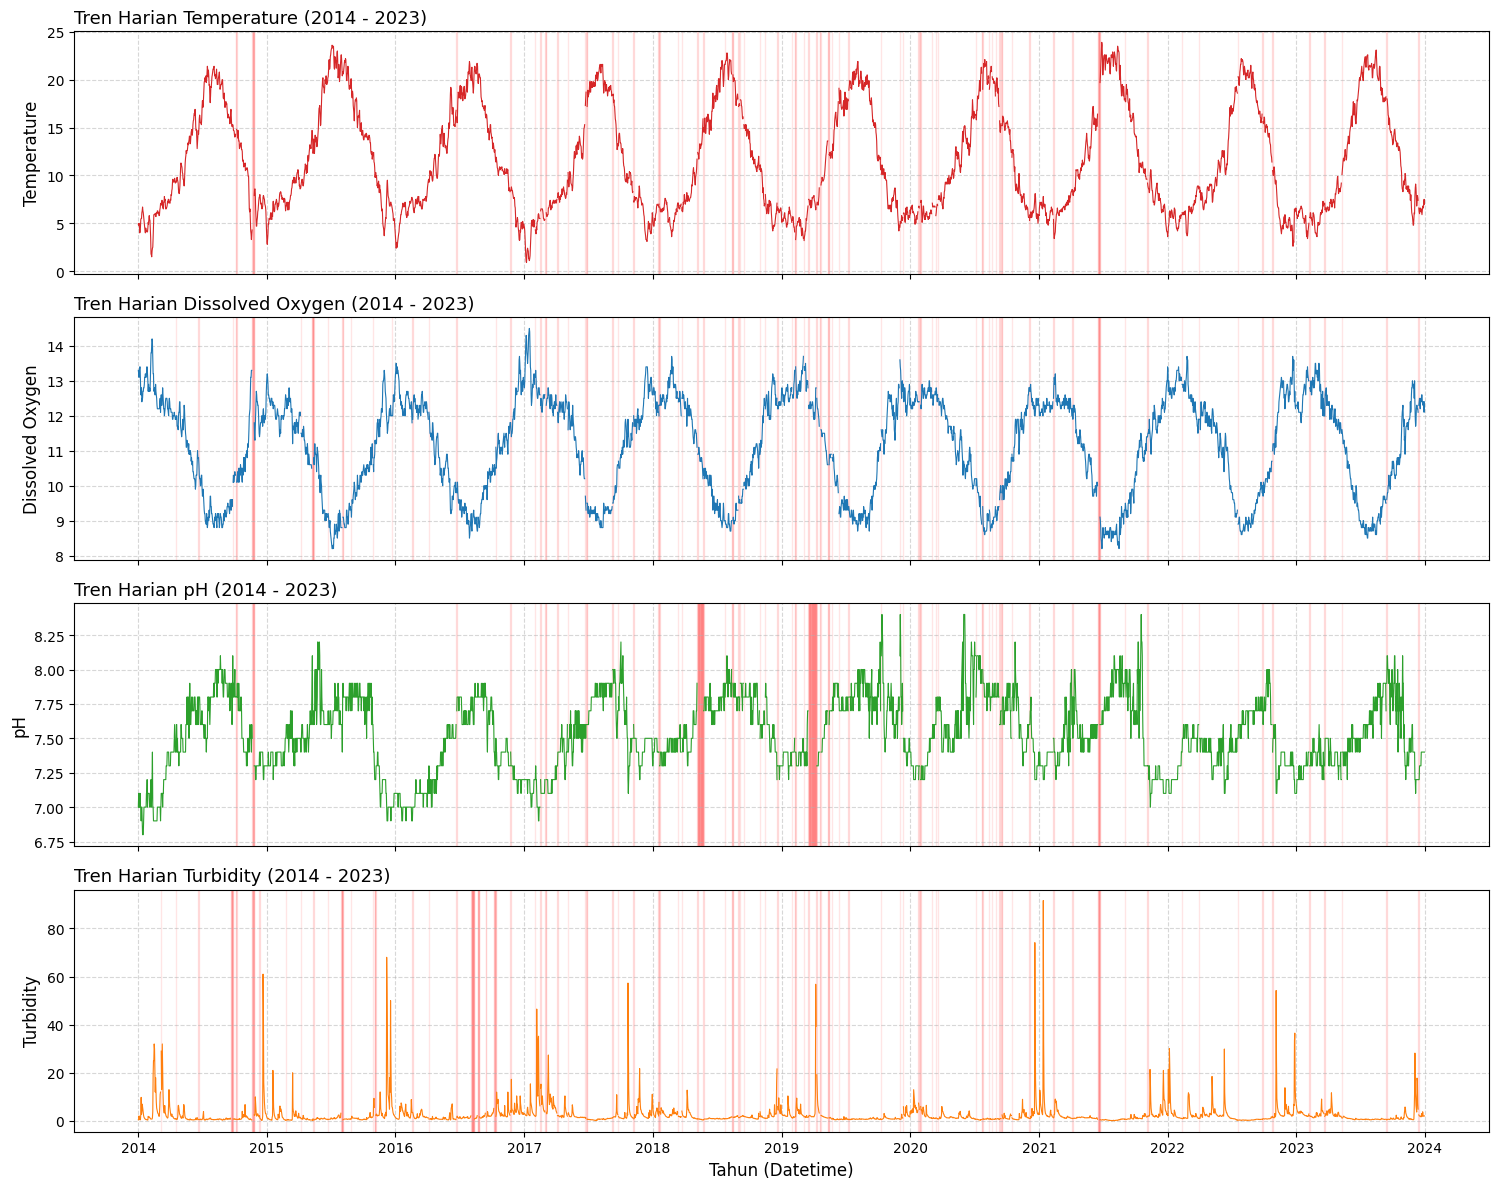

In [9]:
features = ['Temperature', 'Dissolved Oxygen', 'pH', 'Turbidity']
colors = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e']

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 12), sharex=True)

for i, col in enumerate(features):
    axes[i].plot(df.index, df[col], color=colors[i], linewidth=0.8)
    axes[i].set_ylabel(col, fontsize=12)
    axes[i].set_title(f"Tren Harian {col} (2014 - 2023)", fontsize=13, loc='left')
    axes[i].grid(True, linestyle='--', alpha=0.5)

    missing_mask = df[col].isna()
    for j in range(len(missing_mask) - 1):
        if missing_mask.iloc[j]:
            axes[i].axvspan(df.index[j], df.index[j+1], color='red', alpha=0.1)

plt.xlabel("Tahun (Datetime)", fontsize=12)
plt.tight_layout()
plt.show()

### Step 3.C - Distribusi Tiap Parameter

Histogram + boxplot untuk melihat skewness, ekor distribusi, dan keberadaan outlier alami pada setiap parameter.

In [10]:
def plot_distribution(df, column, color):
    fig = px.histogram(
        df, x=column, marginal="box",
        title=f"Distribusi dan Boxplot Historis: {column}",
        color_discrete_sequence=[color],
        opacity=0.8, nbins=50,
    )
    fig.update_layout(
        xaxis_title=f"Nilai {column}",
        yaxis_title="Frekuensi (Jumlah Hari)",
        bargap=0.05, plot_bgcolor='white',
    )
    fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
    fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
    fig.show()

plot_distribution(df, 'Temperature',      '#EF553B')
plot_distribution(df, 'Dissolved Oxygen', '#00CC96')
plot_distribution(df, 'pH',               '#AB63FA')
plot_distribution(df, 'Turbidity',        '#FFA15A')

### Step 3.D - Matriks Korelasi

Korelasi antar parameter penting untuk memahami apakah ada redundansi atau hubungan yang kuat. Misalnya, Temperature dan Dissolved Oxygen biasanya berkorelasi negatif (semakin hangat, semakin rendah DO).

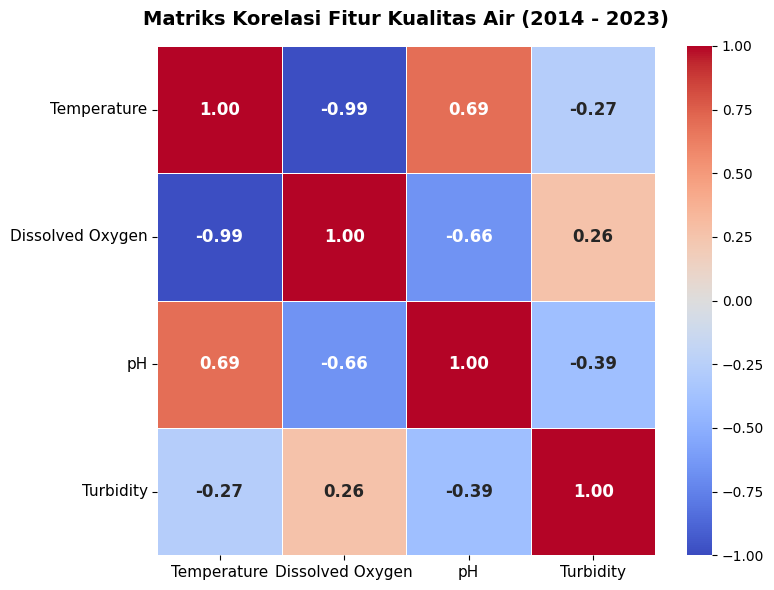

In [11]:
corr_matrix = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
    linewidths=0.5, vmin=-1, vmax=1,
    annot_kws={"size": 12, "weight": "bold"}
)
plt.title("Matriks Korelasi Fitur Kualitas Air (2014 - 2023)", fontsize=14, fontweight='bold', pad=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.show()

## Step 4 - Data Cleaning and Imputation

Beberapa hari memiliki nilai kosong (`NaN`) baik karena sensor mati maupun karena hasil reindex. Pada penelitian ini imputasi dilakukan dengan kombinasi `bfill` (mengisi dengan nilai berikutnya) lalu `ffill` (mengisi dengan nilai sebelumnya). Strategi ini dipilih karena:
- Data bersifat deret waktu yang berkorelasi temporal.
- Nilai sensor kualitas air cenderung berubah perlahan dari hari ke hari.
- Sederhana, deterministik, dan tidak memerlukan model tambahan.

In [12]:
print("--- Missing Values SEBELUM Imputasi ---")
print(df.isna().sum())

--- Missing Values SEBELUM Imputasi ---
Temperature          92
Dissolved Oxygen    111
pH                  130
Turbidity           140
dtype: int64


In [13]:
df = df.bfill().ffill()

print("--- Missing Values SESUDAH Imputasi ---")
print(df.isna().sum())

--- Missing Values SESUDAH Imputasi ---
Temperature         0
Dissolved Oxygen    0
pH                  0
Turbidity           0
dtype: int64


In [14]:
print("--- 5 Baris Pertama Data Bersih ---")
df.head()

--- 5 Baris Pertama Data Bersih ---


,Temperature,Dissolved Oxygen,pH,Turbidity
datetime,,,,
2014-01-01 00:00:00+00:00,4.9,13.3,7.0,0.5
2014-01-02 00:00:00+00:00,4.8,13.2,7.1,0.5
2014-01-03 00:00:00+00:00,5.0,13.1,7.0,2.1
2014-01-04 00:00:00+00:00,4.6,13.3,7.1,1.0
2014-01-05 00:00:00+00:00,4.0,13.4,7.0,0.6


## Step 5 - Feature Engineering

Untuk menangkap konteks temporal yang tidak bisa dilihat oleh model jika hanya melihat satu titik waktu, dilakukan rekayasa fitur:

1. **Log transform pada Turbidity** → distribusi turbidity sangat right-skewed sehingga `np.log1p` digunakan untuk menstabilkan varians.
2. **Encoding siklus tahunan (Month_Sin, Month_Cos)** → menjaga sifat siklik bulan (Desember dekat dengan Januari).
3. **First-order difference (`*_Diff`)** → menangkap perubahan tiba-tiba antar hari.
4. **Rolling mean 7 hari (`*_Mean_7D`)** → konteks rata-rata mingguan.
5. **Rolling std 7 hari (`*_Std_7D`)** → volatilitas mingguan.

> **Catatan perbaikan**: Log transform Turbidity dilakukan terlebih dahulu pada `df_feat`, bukan pada `df` lama, supaya seluruh fitur turunan Turbidity (Diff, Mean_7D, Std_7D) konsisten dihitung dari versi log-transformed. Pada notebook sebelumnya log transform diterapkan ke `df` setelah `df_feat = df.copy()` sehingga tidak pernah benar-benar dipakai.

In [15]:
df_feat = df.copy()

# 1. Log transform pada Turbidity (right-skewed)
df_feat['Turbidity'] = np.log1p(df_feat['Turbidity'])

# 2. Cyclical encoding bulan
df_feat['Month_Sin'] = np.sin(2 * np.pi * df_feat.index.month / 12)
df_feat['Month_Cos'] = np.cos(2 * np.pi * df_feat.index.month / 12)

# 3-5. Diff, rolling mean, rolling std untuk setiap fitur utama
for col in features:
    df_feat[f'{col}_Diff']    = df_feat[col].diff()
    df_feat[f'{col}_Mean_7D'] = df_feat[col].rolling(window=7, min_periods=1).mean()
    df_feat[f'{col}_Std_7D']  = df_feat[col].rolling(window=7, min_periods=2).std()

# Mengisi NaN akibat .diff() dan .rolling() di awal seri
df_feat = df_feat.bfill()

print("--- Info Struktur Data Setelah Feature Engineering ---")
df_feat.info()

--- Info Struktur Data Setelah Feature Engineering ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3652 entries, 2014-01-01 00:00:00+00:00 to 2023-12-31 00:00:00+00:00
Freq: D
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               3652 non-null   float64
 1   Dissolved Oxygen          3652 non-null   float64
 2   pH                        3652 non-null   float64
 3   Turbidity                 3652 non-null   float64
 4   Month_Sin                 3652 non-null   float64
 5   Month_Cos                 3652 non-null   float64
 6   Temperature_Diff          3652 non-null   float64
 7   Temperature_Mean_7D       3652 non-null   float64
 8   Temperature_Std_7D        3652 non-null   float64
 9   Dissolved Oxygen_Diff     3652 non-null   float64
 10  Dissolved Oxygen_Mean_7D  3652 non-null   float64
 11  Dissolved Oxygen_Std_7D   3652 non-null   float64
 12  pH_Diff

In [16]:
print("--- Contoh Hasil Rekayasa Fitur (Fokus di Temperature) ---")
df_feat[['Temperature', 'Temperature_Diff', 'Temperature_Mean_7D', 'Temperature_Std_7D']].head()

--- Contoh Hasil Rekayasa Fitur (Fokus di Temperature) ---


,Temperature,Temperature_Diff,Temperature_Mean_7D,Temperature_Std_7D
datetime,,,,
2014-01-01 00:00:00+00:00,4.9,-0.1,4.900,0.070711
2014-01-02 00:00:00+00:00,4.8,-0.1,4.850,0.070711
2014-01-03 00:00:00+00:00,5.0,0.2,4.900,0.100000
2014-01-04 00:00:00+00:00,4.6,-0.4,4.825,0.170783
2014-01-05 00:00:00+00:00,4.0,-0.6,4.660,0.397492


### Step 5.A - Visualisasi Efek Log Transform pada Turbidity

Visualisasi sebelum vs sesudah log transform untuk membuktikan distribusi menjadi lebih simetris.

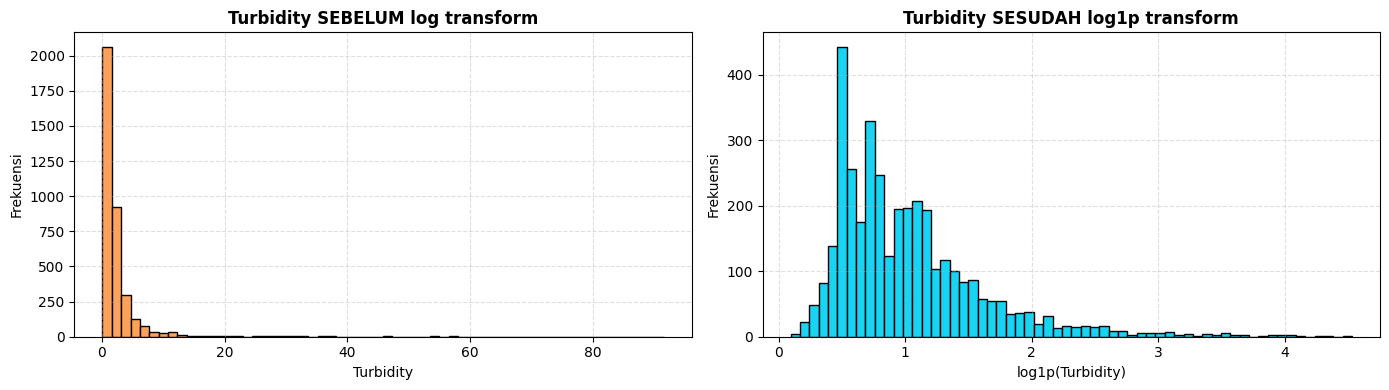

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Turbidity'].dropna(), bins=60, color='#FFA15A', edgecolor='black')
axes[0].set_title("Turbidity SEBELUM log transform", fontweight='bold')
axes[0].set_xlabel("Turbidity")
axes[0].set_ylabel("Frekuensi")
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].hist(df_feat['Turbidity'].dropna(), bins=60, color='#19D3F3', edgecolor='black')
axes[1].set_title("Turbidity SESUDAH log1p transform", fontweight='bold')
axes[1].set_xlabel("log1p(Turbidity)")
axes[1].set_ylabel("Frekuensi")
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Step 6 - Data Splitting

Karena data adalah deret waktu, splitting **TIDAK** boleh dilakukan secara acak (random). Splitting harus mengikuti urutan waktu agar tidak terjadi *data leakage* dari masa depan ke masa lalu:

| Subset       | Periode       | Tujuan                                  |
|--------------|---------------|-----------------------------------------|
| Training     | 2014 – 2020   | Melatih model (data normal saja)        |
| Validation   | 2021          | Hyperparameter tuning                   |
| Test         | 2022 – 2023   | Evaluasi akhir + ensemble + ablasi      |

In [18]:
train_df = df_feat.loc['2014':'2020'].copy()
val_df   = df_feat.loc['2021'].copy()
test_df  = df_feat.loc['2022':'2023'].copy()

print(f"Train : {train_df.shape[0]} hari ({train_df.index.min().date()} -> {train_df.index.max().date()})")
print(f"Val   : {val_df.shape[0]} hari ({val_df.index.min().date()} -> {val_df.index.max().date()})")
print(f"Test  : {test_df.shape[0]} hari ({test_df.index.min().date()} -> {test_df.index.max().date()})")

Train : 2557 hari (2014-01-01 -> 2020-12-31)
Val   : 365 hari (2021-01-01 -> 2021-12-31)
Test  : 730 hari (2022-01-01 -> 2023-12-31)


## Step 7 - Standardization

Algoritma berbasis jarak (LOF) maupun berbasis margin (OCSVM) sangat sensitif terhadap skala fitur. `RobustScaler` dipilih karena tahan terhadap outlier (menggunakan median dan IQR, bukan mean dan std). Scaler **hanya difit pada data training** untuk menghindari leakage.

Fitur cyclical (`Month_Sin`, `Month_Cos`) tidak diskalakan karena nilainya sudah berada di rentang [-1, 1].

In [19]:
cyclical_cols = ['Month_Sin', 'Month_Cos']
cols_to_scale = [c for c in train_df.columns if c not in cyclical_cols]

scaler = RobustScaler()
scaler.fit(train_df[cols_to_scale])

def scale_dataframe(df_target, scaler_obj, scale_cols, pass_cols):
    scaled_array = scaler_obj.transform(df_target[scale_cols])
    df_scaled = pd.DataFrame(scaled_array, columns=scale_cols, index=df_target.index)
    return pd.concat([df_scaled, df_target[pass_cols]], axis=1)

train_scaled = scale_dataframe(train_df, scaler, cols_to_scale, cyclical_cols)
val_scaled   = scale_dataframe(val_df,   scaler, cols_to_scale, cyclical_cols)
test_scaled  = scale_dataframe(test_df,  scaler, cols_to_scale, cyclical_cols)

print("--- Contoh Data Train Set Setelah Scaling ---")
train_scaled[['Temperature', 'Turbidity', 'Month_Sin', 'Month_Cos']].head()

--- Contoh Data Train Set Setelah Scaling ---


,Temperature,Turbidity,Month_Sin,Month_Cos
datetime,,,,
2014-01-01 00:00:00+00:00,-0.569892,-0.706798,0.5,0.866025
2014-01-02 00:00:00+00:00,-0.580645,-0.706798,0.5,0.866025
2014-01-03 00:00:00+00:00,-0.559140,0.384876,0.5,0.866025
2014-01-04 00:00:00+00:00,-0.602151,-0.274178,0.5,0.866025
2014-01-05 00:00:00+00:00,-0.666667,-0.609744,0.5,0.866025


## Step 8 - Synthetic Anomaly Injection

Karena dataset tidak memiliki label anomali, ground truth dibuat secara sintetik dengan dua skenario:

- **Skenario 1 (Univariat — Sensor Failure)**: nilai `Turbidity` ditambah lonjakan besar pada hari acak. Mensimulasikan biofouling atau probe rusak.
- **Skenario 2 (Multivariat — Pollution Event)**: `Temperature` naik DAN `Dissolved Oxygen` turun secara bersamaan. Mensimulasikan pencemaran termal.

> **Catatan perbaikan penting**: Pada notebook sebelumnya, hanya kolom mentah (Temperature, Turbidity, Dissolved Oxygen) yang dimodifikasi. Padahal model dilatih dengan fitur turunan (`*_Diff`, `*_Mean_7D`, `*_Std_7D`) — sehingga anomali tidak tercermin pada fitur yang sebenarnya dilihat model. Versi baru ini **menghitung ulang fitur turunan** setelah injeksi agar evaluasi realistis.

In [20]:
def inject_anomalies(df_in, base_features, num_univariate=5, num_multivariate=5, seed=42):
    rng = np.random.default_rng(seed)
    df_injected = df_in.copy()
    df_injected['Label'] = 0

    # SKENARIO 1: UNIVARIAT (Turbidity spike)
    idx_pool = df_injected.index.to_numpy()
    random_dates_uni = rng.choice(idx_pool, size=num_univariate, replace=False)
    for date in random_dates_uni:
        df_injected.loc[date, 'Turbidity'] += 5.0
        df_injected.loc[date, 'Label'] = 1

    # SKENARIO 2: MULTIVARIAT (Temperature naik + DO turun)
    remaining = df_injected.index[df_injected['Label'] == 0].to_numpy()
    random_dates_multi = rng.choice(remaining, size=num_multivariate, replace=False)
    for date in random_dates_multi:
        df_injected.loc[date, 'Temperature']      += 5.0
        df_injected.loc[date, 'Dissolved Oxygen'] -= 5.0
        df_injected.loc[date, 'Label'] = 1

    # PENTING: Hitung ulang fitur turunan agar konsisten dengan kolom mentah yang sudah diinjeksi
    for col in base_features:
        df_injected[f'{col}_Diff']    = df_injected[col].diff()
        df_injected[f'{col}_Mean_7D'] = df_injected[col].rolling(window=7, min_periods=1).mean()
        df_injected[f'{col}_Std_7D']  = df_injected[col].rolling(window=7, min_periods=2).std()
    df_injected = df_injected.bfill()

    return df_injected

In [21]:
val_injected  = inject_anomalies(val_scaled,  features, num_univariate=36, num_multivariate=36, seed=42)
test_injected = inject_anomalies(test_scaled, features, num_univariate=72, num_multivariate=72, seed=43)

print("--- Laporan Ground Truth Buatan ---")
print(f"Total Hari Normal di Validation Set  : {(val_injected['Label']==0).sum()}")
print(f"Total Hari Anomali di Validation Set : {(val_injected['Label']==1).sum()}")
print(f"Total Hari Normal di Test Set        : {(test_injected['Label']==0).sum()}")
print(f"Total Hari Anomali di Test Set       : {(test_injected['Label']==1).sum()}")

--- Laporan Ground Truth Buatan ---
Total Hari Normal di Validation Set  : 293
Total Hari Anomali di Validation Set : 72
Total Hari Normal di Test Set        : 586
Total Hari Anomali di Test Set       : 144


In [22]:
print("--- Contoh Data Anomali Multivariat di Test Set ---")
test_injected[test_injected['Label']==1][['Temperature','Dissolved Oxygen','Turbidity','Label']].tail(3)

--- Contoh Data Anomali Multivariat di Test Set ---


,Temperature,Dissolved Oxygen,Turbidity,Label
datetime,,,,
2023-12-20 00:00:00+00:00,4.580645,-4.583333,0.335566,1
2023-12-24 00:00:00+00:00,4.537634,-4.500000,0.284585,1
2023-12-31 00:00:00+00:00,4.655914,-4.583333,0.384876,1


### Step 8.A - Visualisasi Lokasi Anomali yang Diinjeksi

Plot ini membantu memvisualisasikan letak anomali sintetik pada deret waktu test set, sehingga pembaca laporan bisa memahami secara intuitif apa yang dideteksi model.

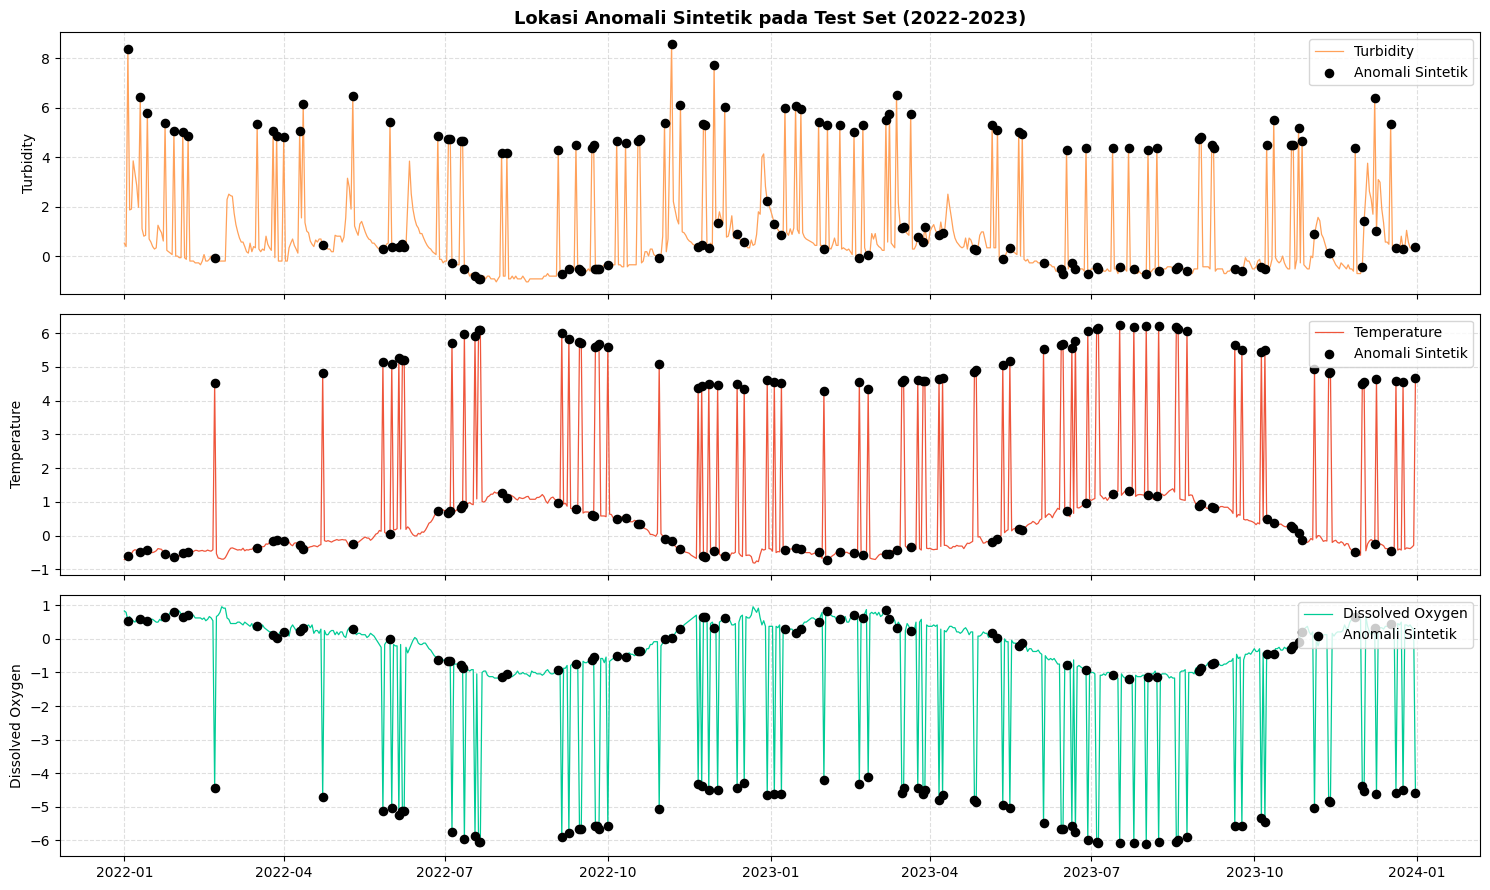

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
plot_cols = ['Turbidity', 'Temperature', 'Dissolved Oxygen']
plot_colors = ['#FFA15A', '#EF553B', '#00CC96']

anomaly_mask = test_injected['Label'] == 1

for ax, col, c in zip(axes, plot_cols, plot_colors):
    ax.plot(test_injected.index, test_injected[col], color=c, linewidth=0.9, label=col)
    ax.scatter(
        test_injected.index[anomaly_mask], test_injected[col][anomaly_mask],
        color='black', s=35, zorder=5, label='Anomali Sintetik'
    )
    ax.set_ylabel(col)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper right')

axes[0].set_title("Lokasi Anomali Sintetik pada Test Set (2022-2023)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 9 - Pipeline Kelas dan Baseline Training

Kelas `AnomalyPipeline` dibuat agar kode lebih rapi dan reusable. Kelas ini:
- Menerima nama model + parameter (sehingga kita bisa pakai parameter terbaik dari tuning).
- Menyediakan `fit` (training pada data normal) dan `evaluate` (prediksi + classification report + visualisasi + confusion matrix).

> **Catatan perbaikan**: Pada versi lama, kelas `AnomalyPipeline` selalu dibuat dengan parameter default. Akibatnya, "Final Model Evaluation" pada test set sama sekali tidak menggunakan hasil hyperparameter tuning. Versi baru menerima `**model_kwargs` agar parameter terbaik bisa dimasukkan.

In [24]:
class AnomalyPipeline:
    def __init__(self, model_name, **model_kwargs):
        self.model_name = model_name.upper()
        self.model_kwargs = model_kwargs

        if self.model_name == 'LOF':
            defaults = {'n_neighbors': 20, 'novelty': True}
            defaults.update(model_kwargs)
            defaults['novelty'] = True  # wajib True agar bisa predict pada data baru
            self.model = LocalOutlierFactor(**defaults)
        elif self.model_name == 'OCSVM':
            defaults = {'kernel': 'rbf', 'gamma': 'scale', 'nu': 0.01}
            defaults.update(model_kwargs)
            self.model = OneClassSVM(**defaults)
        else:
            raise ValueError("Model tidak valid. Pilih 'LOF' atau 'OCSVM'.")

    def fit(self, train_df, feature_cols):
        self.feature_cols = feature_cols
        self.model.fit(train_df[feature_cols].values)
        return self

    def predict(self, df_eval):
        preds = self.model.predict(df_eval[self.feature_cols].values)
        return np.array([1 if x == -1 else 0 for x in preds])

    def decision_scores(self, df_eval):
        # Skor tinggi = lebih anomali
        return -1.0 * self.model.decision_function(df_eval[self.feature_cols].values)

    def evaluate(self, df_eval, title_suffix=""):
        preds_mapped = self.predict(df_eval)
        scores = self.decision_scores(df_eval)
        y_true = df_eval['Label'].values

        print(f"--- LAPORAN KLASIFIKASI {self.model_name} {title_suffix} ---")
        print(classification_report(
            y_true, preds_mapped,
            target_names=['Normal', 'Anomali'], zero_division=0
        ))

        # Plot anomaly score timeline
        fig, ax = plt.subplots(figsize=(15, 5))
        ax.plot(df_eval.index, scores, color='gray', alpha=0.6,
                label=f'Anomaly Score ({self.model_name})')
        ax.axhline(y=0, color='red', linestyle='--', linewidth=2,
                   label='Threshold (Score > 0 = Anomali)')

        anomaly_mask = (y_true == 1)
        pred_mask = (preds_mapped == 1)

        ax.scatter(df_eval.index[anomaly_mask], scores[anomaly_mask],
                   color='blue', s=120, label='Ground Truth',
                   edgecolors='black', zorder=5)
        ax.scatter(df_eval.index[pred_mask], scores[pred_mask],
                   color='red', s=80, marker='x', label='Prediksi Model', zorder=6)

        ax.set_title(f"Deteksi Anomali Kualitas Air - {self.model_name} {title_suffix}",
                     fontsize=14, fontweight='bold')
        ax.set_ylabel("Anomaly Score")
        ax.legend(loc='upper right')
        ax.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

        # Plot confusion matrix
        cm = confusion_matrix(y_true, preds_mapped)
        fig, ax = plt.subplots(figsize=(4.5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=['Normal', 'Anomali'],
                    yticklabels=['Normal', 'Anomali'], ax=ax)
        ax.set_xlabel("Prediksi")
        ax.set_ylabel("Ground Truth")
        ax.set_title(f"Confusion Matrix - {self.model_name} {title_suffix}",
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

        return preds_mapped, scores

### Step 9.A - Baseline LOF (parameter default) pada Validation Set

--- LAPORAN KLASIFIKASI LOF (Baseline - Validation) ---
              precision    recall  f1-score   support

      Normal       0.92      0.77      0.84       293
     Anomali       0.44      0.71      0.54        72

    accuracy                           0.76       365
   macro avg       0.68      0.74      0.69       365
weighted avg       0.82      0.76      0.78       365



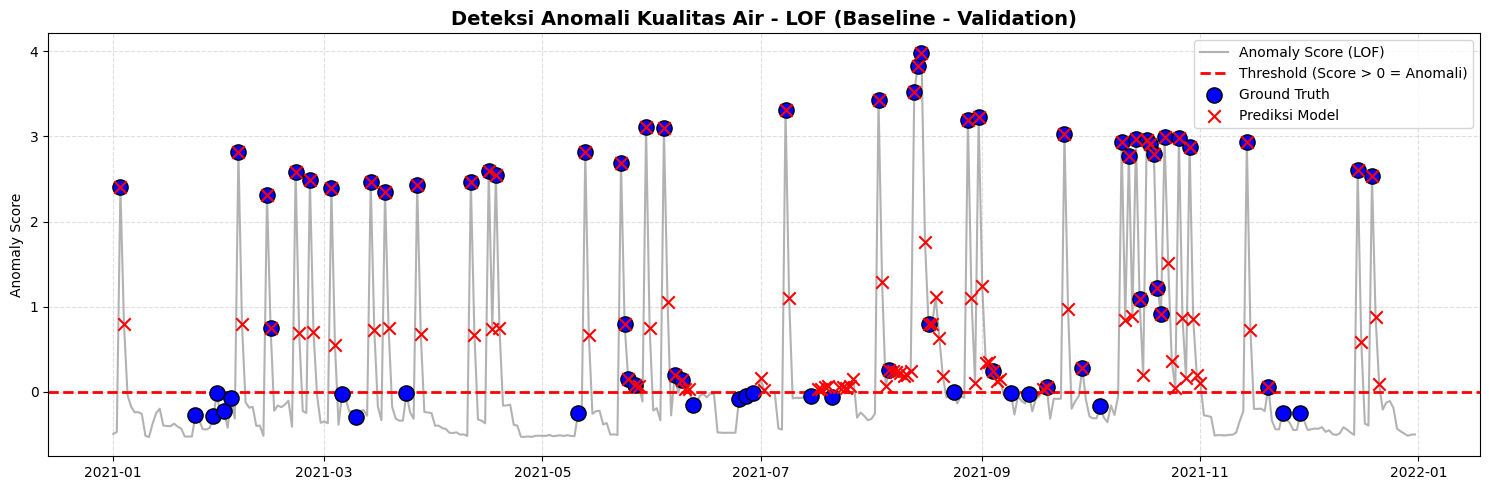

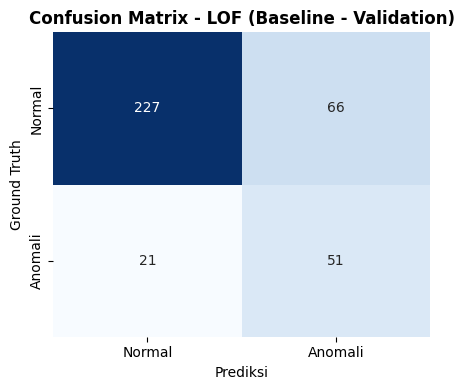

In [25]:
features_model = [c for c in train_scaled.columns]  # semua fitur engineered
pipeline_lof_base = AnomalyPipeline('LOF').fit(train_scaled, features_model)
_ = pipeline_lof_base.evaluate(val_injected, title_suffix="(Baseline - Validation)")

### Step 9.B - Baseline OCSVM (parameter default) pada Validation Set

--- LAPORAN KLASIFIKASI OCSVM (Baseline - Validation) ---
              precision    recall  f1-score   support

      Normal       1.00      0.79      0.88       293
     Anomali       0.54      1.00      0.70        72

    accuracy                           0.83       365
   macro avg       0.77      0.89      0.79       365
weighted avg       0.91      0.83      0.85       365



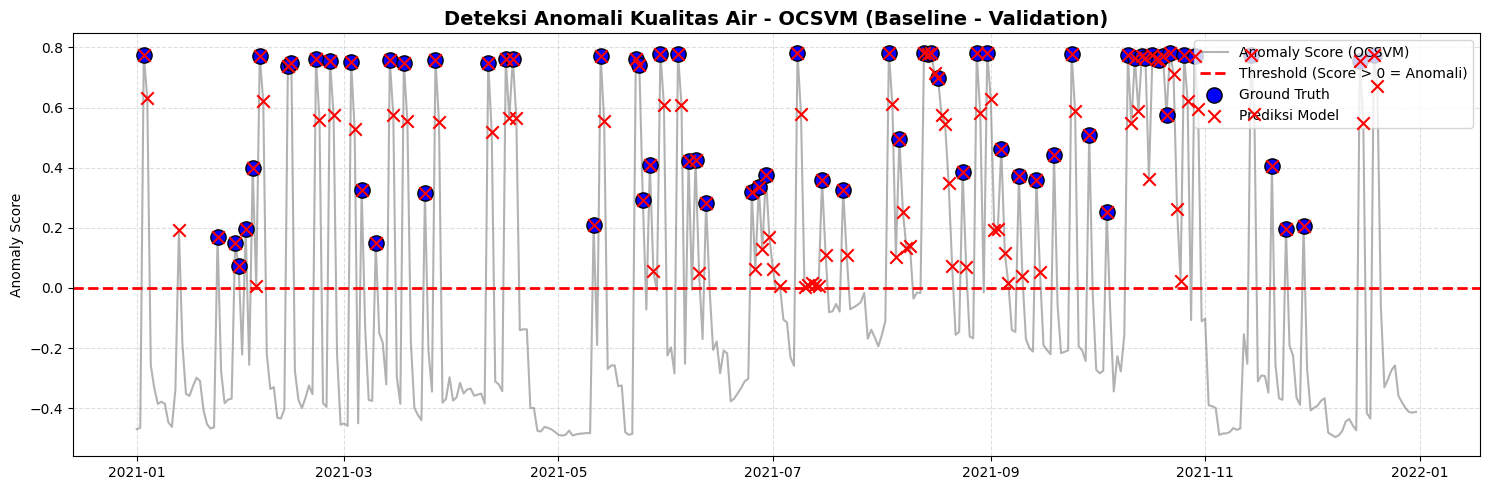

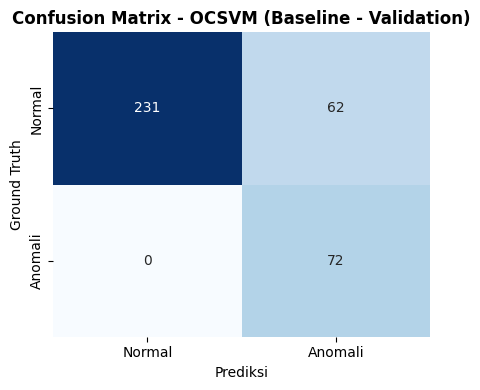

In [26]:
pipeline_svm_base = AnomalyPipeline('OCSVM').fit(train_scaled, features_model)
_ = pipeline_svm_base.evaluate(val_injected, title_suffix="(Baseline - Validation)")

## Step 10 - Hyperparameter Tuning

Tuning dilakukan pada **validation set** dengan grid sederhana. Metrik utama adalah F1-Score karena kelas tidak seimbang. Hasil tuning juga divisualisasikan dalam bentuk heatmap untuk menunjukkan sensitivitas model terhadap parameter.

### Step 10.A - Tuning LOF

In [27]:
lof_neighbors      = [10, 20, 30, 50]
lof_contaminations = [0.01, 0.03, 0.05, 0.1]

lof_results = []
best_lof_f1 = 0
best_lof_params = {}

for n in lof_neighbors:
    for c in lof_contaminations:
        model = LocalOutlierFactor(n_neighbors=n, contamination=c, novelty=True)
        model.fit(train_scaled[features_model].values)
        preds = model.predict(val_injected[features_model].values)
        preds_mapped = [1 if x == -1 else 0 for x in preds]

        acc = accuracy_score(val_injected['Label'], preds_mapped)
        f1  = f1_score(val_injected['Label'], preds_mapped, zero_division=0)

        lof_results.append({'n_neighbors': n, 'contamination': c, 'Accuracy': acc, 'F1-Score': f1})
        print(f"Uji n_neighbors={n:2d}, contamination={c:.2f} | Akurasi: {acc:.4f} | F1: {f1:.4f}")

        if f1 > best_lof_f1:
            best_lof_f1 = f1
            best_lof_params = {'n_neighbors': n, 'contamination': c}

print(f"\n[LOF TERBAIK] {best_lof_params} | F1-Score: {best_lof_f1:.4f}")

Uji n_neighbors=10, contamination=0.01 | Akurasi: 0.8164 | F1: 0.6492
Uji n_neighbors=10, contamination=0.03 | Akurasi: 0.6795 | F1: 0.5263
Uji n_neighbors=10, contamination=0.05 | Akurasi: 0.6219 | F1: 0.4851
Uji n_neighbors=10, contamination=0.10 | Akurasi: 0.5342 | F1: 0.4371
Uji n_neighbors=20, contamination=0.01 | Akurasi: 0.7973 | F1: 0.5698
Uji n_neighbors=20, contamination=0.03 | Akurasi: 0.6877 | F1: 0.5250
Uji n_neighbors=20, contamination=0.05 | Akurasi: 0.6411 | F1: 0.4981
Uji n_neighbors=20, contamination=0.10 | Akurasi: 0.5671 | F1: 0.4662
Uji n_neighbors=30, contamination=0.01 | Akurasi: 0.7781 | F1: 0.5318
Uji n_neighbors=30, contamination=0.03 | Akurasi: 0.7178 | F1: 0.5339
Uji n_neighbors=30, contamination=0.05 | Akurasi: 0.6384 | F1: 0.4884
Uji n_neighbors=30, contamination=0.10 | Akurasi: 0.5699 | F1: 0.4642
Uji n_neighbors=50, contamination=0.01 | Akurasi: 0.8027 | F1: 0.5500
Uji n_neighbors=50, contamination=0.03 | Akurasi: 0.6986 | F1: 0.4860
Uji n_neighbors=50, 

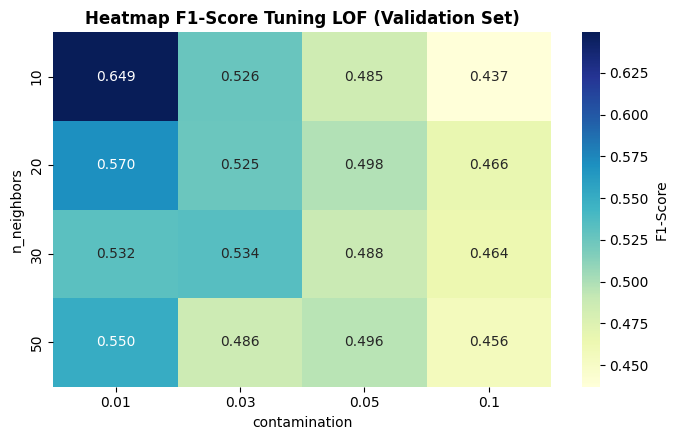

In [28]:
# Visualisasi hasil tuning LOF sebagai heatmap F1-Score
lof_df = pd.DataFrame(lof_results)
lof_pivot = lof_df.pivot(index='n_neighbors', columns='contamination', values='F1-Score')

plt.figure(figsize=(7, 4.5))
sns.heatmap(lof_pivot, annot=True, fmt=".3f", cmap='YlGnBu', cbar_kws={'label': 'F1-Score'})
plt.title("Heatmap F1-Score Tuning LOF (Validation Set)", fontweight='bold')
plt.xlabel("contamination")
plt.ylabel("n_neighbors")
plt.tight_layout()
plt.show()

### Step 10.B - Tuning OCSVM

In [29]:
svm_nus    = [0.01, 0.03, 0.05, 0.1]
svm_gammas = ['scale', 'auto', 0.01, 0.1]

svm_results = []
best_svm_f1 = 0
best_svm_params = {}

for nu in svm_nus:
    for g in svm_gammas:
        model = OneClassSVM(kernel='rbf', gamma=g, nu=nu)
        model.fit(train_scaled[features_model].values)
        preds = model.predict(val_injected[features_model].values)
        preds_mapped = [1 if x == -1 else 0 for x in preds]

        acc = accuracy_score(val_injected['Label'], preds_mapped)
        f1  = f1_score(val_injected['Label'], preds_mapped, zero_division=0)

        svm_results.append({'nu': nu, 'gamma': str(g), 'Accuracy': acc, 'F1-Score': f1})
        print(f"Uji nu={nu:.2f}, gamma={str(g):>5s} | Akurasi: {acc:.4f} | F1: {f1:.4f}")

        if f1 > best_svm_f1:
            best_svm_f1 = f1
            best_svm_params = {'nu': nu, 'gamma': g}

print(f"\n[OCSVM TERBAIK] {best_svm_params} | F1-Score: {best_svm_f1:.4f}")

Uji nu=0.01, gamma=scale | Akurasi: 0.8301 | F1: 0.6990
Uji nu=0.01, gamma= auto | Akurasi: 0.8603 | F1: 0.7385
Uji nu=0.01, gamma= 0.01 | Akurasi: 0.8356 | F1: 0.5833
Uji nu=0.01, gamma=  0.1 | Akurasi: 0.7644 | F1: 0.6261
Uji nu=0.03, gamma=scale | Akurasi: 0.8247 | F1: 0.6923
Uji nu=0.03, gamma= auto | Akurasi: 0.8521 | F1: 0.7273
Uji nu=0.03, gamma= 0.01 | Akurasi: 0.8411 | F1: 0.6133
Uji nu=0.03, gamma=  0.1 | Akurasi: 0.7644 | F1: 0.6261
Uji nu=0.05, gamma=scale | Akurasi: 0.8301 | F1: 0.6990
Uji nu=0.05, gamma= auto | Akurasi: 0.8384 | F1: 0.7094
Uji nu=0.05, gamma= 0.01 | Akurasi: 0.8493 | F1: 0.6893
Uji nu=0.05, gamma=  0.1 | Akurasi: 0.7616 | F1: 0.6234
Uji nu=0.10, gamma=scale | Akurasi: 0.8082 | F1: 0.6729
Uji nu=0.10, gamma= auto | Akurasi: 0.8137 | F1: 0.6792
Uji nu=0.10, gamma= 0.01 | Akurasi: 0.8274 | F1: 0.6957
Uji nu=0.10, gamma=  0.1 | Akurasi: 0.7589 | F1: 0.6207

[OCSVM TERBAIK] {'nu': 0.01, 'gamma': 'auto'} | F1-Score: 0.7385


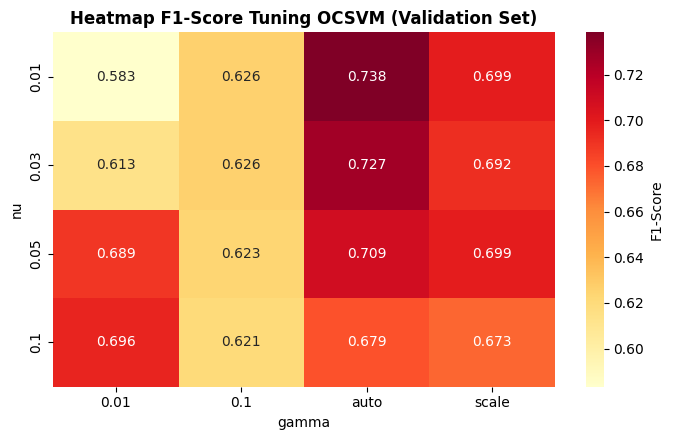

In [30]:
# Visualisasi hasil tuning OCSVM
svm_df = pd.DataFrame(svm_results)
svm_pivot = svm_df.pivot(index='nu', columns='gamma', values='F1-Score')

plt.figure(figsize=(7, 4.5))
sns.heatmap(svm_pivot, annot=True, fmt=".3f", cmap='YlOrRd', cbar_kws={'label': 'F1-Score'})
plt.title("Heatmap F1-Score Tuning OCSVM (Validation Set)", fontweight='bold')
plt.xlabel("gamma")
plt.ylabel("nu")
plt.tight_layout()
plt.show()

## Step 11 - Final Model Evaluation pada Test Set

Sekarang model dilatih ulang dengan **parameter terbaik** dari tuning lalu dievaluasi pada **test set** (2022–2023) yang belum pernah dilihat oleh proses tuning.

> **Catatan perbaikan**: Pada notebook lama, evaluasi final memakai `AnomalyPipeline('LOF')` tanpa parameter sehingga hasil tuning terbuang. Sekarang parameter terbaik dilewatkan secara eksplisit.

### Step 11.A - Final LOF

--- LAPORAN KLASIFIKASI LOF (Tuned - Test) ---
              precision    recall  f1-score   support

      Normal       0.93      0.81      0.87       586
     Anomali       0.49      0.75      0.60       144

    accuracy                           0.80       730
   macro avg       0.71      0.78      0.73       730
weighted avg       0.84      0.80      0.81       730



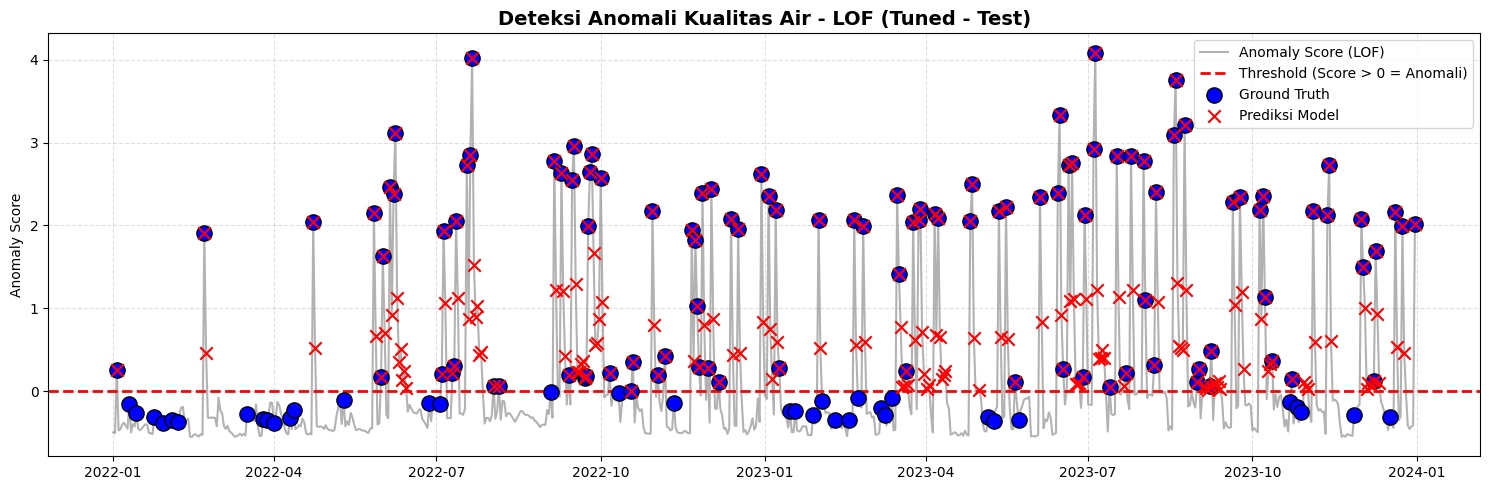

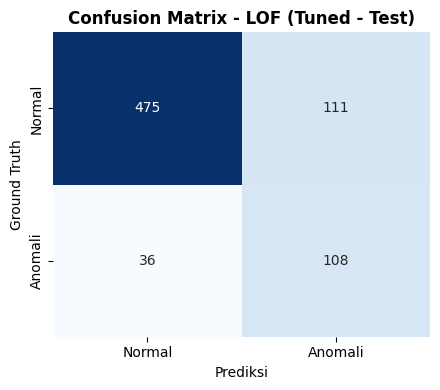

In [31]:
pipeline_lof_final = AnomalyPipeline('LOF', **best_lof_params).fit(train_scaled, features_model)
prediksi_lof_final, _ = pipeline_lof_final.evaluate(test_injected, title_suffix="(Tuned - Test)")

### Step 11.B - Final OCSVM

--- LAPORAN KLASIFIKASI OCSVM (Tuned - Test) ---
              precision    recall  f1-score   support

      Normal       1.00      0.81      0.90       586
     Anomali       0.57      1.00      0.73       144

    accuracy                           0.85       730
   macro avg       0.78      0.91      0.81       730
weighted avg       0.92      0.85      0.86       730



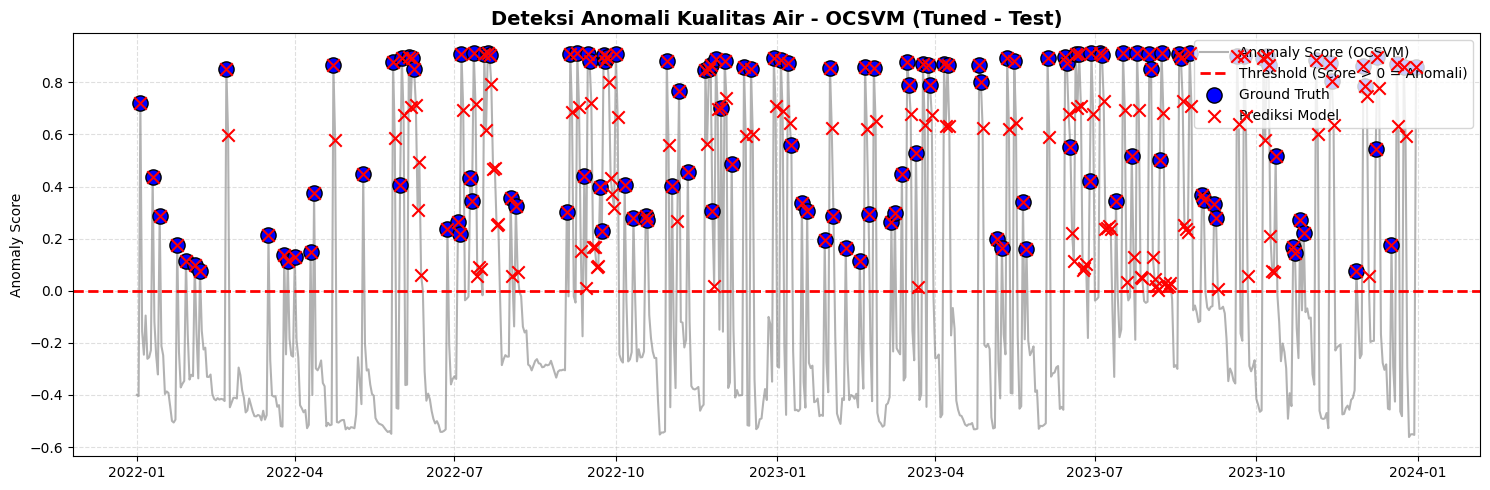

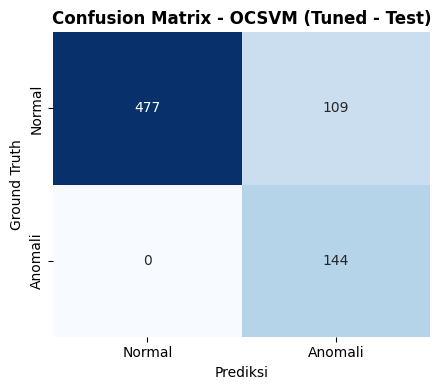

In [32]:
pipeline_svm_final = AnomalyPipeline('OCSVM', **best_svm_params).fit(train_scaled, features_model)
prediksi_svm_final, _ = pipeline_svm_final.evaluate(test_injected, title_suffix="(Tuned - Test)")

## Step 12 - Heterogeneous Ensemble (Majority / AND Vote)

Ensemble menggabungkan prediksi LOF dan OCSVM. Karena hanya ada 2 model, "majority vote" setara dengan **AND vote**: sebuah hari dianggap anomali HANYA jika kedua model setuju. Strategi ini cenderung **menurunkan recall** tetapi **menaikkan precision**, sehingga cocok untuk menekan False Positive.

Selain AND-vote, kita juga menampilkan OR-vote sebagai pembanding (recall lebih tinggi).

In [33]:
test_eval = test_injected.copy()
test_eval['Pred_LOF']  = prediksi_lof_final
test_eval['Pred_SVM']  = prediksi_svm_final

# AND vote (kedua model harus setuju)
test_eval['Pred_Ensemble_AND'] = ((test_eval['Pred_LOF'] == 1) & (test_eval['Pred_SVM'] == 1)).astype(int)
# OR vote (cukup salah satu)
test_eval['Pred_Ensemble_OR']  = ((test_eval['Pred_LOF'] == 1) | (test_eval['Pred_SVM'] == 1)).astype(int)

print("--- ENSEMBLE AND-VOTE (Precision-Oriented) ---")
print(classification_report(test_eval['Label'], test_eval['Pred_Ensemble_AND'],
                            target_names=['Normal', 'Anomali'], zero_division=0))

print("--- ENSEMBLE OR-VOTE (Recall-Oriented) ---")
print(classification_report(test_eval['Label'], test_eval['Pred_Ensemble_OR'],
                            target_names=['Normal', 'Anomali'], zero_division=0))

--- ENSEMBLE AND-VOTE (Precision-Oriented) ---
              precision    recall  f1-score   support

      Normal       0.93      0.85      0.89       586
     Anomali       0.56      0.75      0.64       144

    accuracy                           0.83       730
   macro avg       0.75      0.80      0.77       730
weighted avg       0.86      0.83      0.84       730

--- ENSEMBLE OR-VOTE (Recall-Oriented) ---
              precision    recall  f1-score   support

      Normal       1.00      0.77      0.87       586
     Anomali       0.52      1.00      0.68       144

    accuracy                           0.82       730
   macro avg       0.76      0.88      0.78       730
weighted avg       0.90      0.82      0.83       730



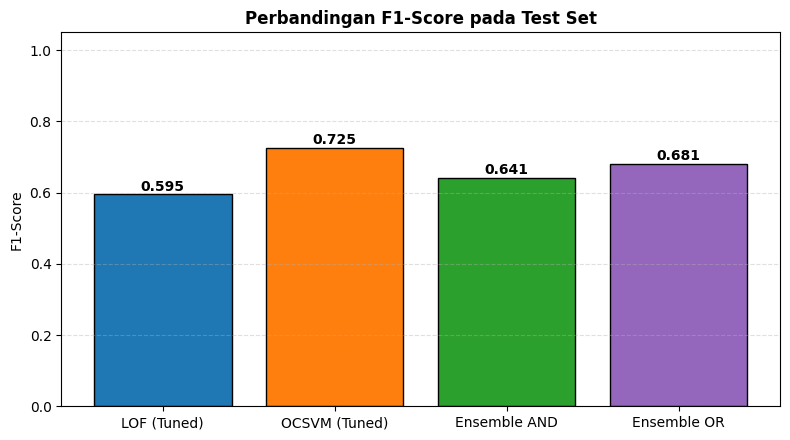

,Model,F1-Score
0,LOF (Tuned),0.595041
1,OCSVM (Tuned),0.725441
2,Ensemble AND,0.640950
3,Ensemble OR,0.680851


In [34]:
# Ringkasan F1-Score keempat strategi
summary = pd.DataFrame({
    'Model': ['LOF (Tuned)', 'OCSVM (Tuned)', 'Ensemble AND', 'Ensemble OR'],
    'F1-Score': [
        f1_score(test_eval['Label'], test_eval['Pred_LOF'], zero_division=0),
        f1_score(test_eval['Label'], test_eval['Pred_SVM'], zero_division=0),
        f1_score(test_eval['Label'], test_eval['Pred_Ensemble_AND'], zero_division=0),
        f1_score(test_eval['Label'], test_eval['Pred_Ensemble_OR'], zero_division=0),
    ]
})

plt.figure(figsize=(8, 4.5))
bars = plt.bar(summary['Model'], summary['F1-Score'],
               color=['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd'], edgecolor='black')
for b, v in zip(bars, summary['F1-Score']):
    plt.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.3f}",
             ha='center', fontweight='bold')
plt.ylim(0, 1.05)
plt.ylabel("F1-Score")
plt.title("Perbandingan F1-Score pada Test Set", fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

summary

## Step 13 - Ablation Study

Tujuan ablation study adalah membuktikan secara empiris bahwa **feature engineering deret waktu** (Diff, Rolling Mean, Rolling Std, Cyclical Encoding) berkontribusi positif terhadap kinerja model. Caranya: latih ulang model terbaik dengan **hanya fitur mentah** (Temperature, Dissolved Oxygen, pH, Turbidity), lalu bandingkan F1-Score-nya dengan versi *full features*.

Skenario yang dibandingkan:
1. **Raw Only** → 4 fitur sensor mentah saja.
2. **Raw + Cyclical** → tambah `Month_Sin`, `Month_Cos`.
3. **Full (Engineered)** → semua fitur (versi yang dipakai di Step 11).

In [35]:
raw_features      = features  # Temperature, Dissolved Oxygen, pH, Turbidity
cyclical_features  = raw_features + ['Month_Sin', 'Month_Cos']
full_features      = features_model

scenarios = {
    'Raw Only':       raw_features,
    'Raw + Cyclical': cyclical_features,
    'Full Engineered': full_features,
}

ablation_results = []

for scenario_name, feat_subset in scenarios.items():
    # LOF
    lof = LocalOutlierFactor(novelty=True, **best_lof_params)
    lof.fit(train_scaled[feat_subset].values)
    pred_lof = lof.predict(test_injected[feat_subset].values)
    pred_lof = np.array([1 if x == -1 else 0 for x in pred_lof])
    f1_lof = f1_score(test_injected['Label'], pred_lof, zero_division=0)

    # OCSVM
    svm = OneClassSVM(kernel='rbf', **best_svm_params)
    svm.fit(train_scaled[feat_subset].values)
    pred_svm = svm.predict(test_injected[feat_subset].values)
    pred_svm = np.array([1 if x == -1 else 0 for x in pred_svm])
    f1_svm = f1_score(test_injected['Label'], pred_svm, zero_division=0)

    # Ensemble AND
    pred_ens = ((pred_lof == 1) & (pred_svm == 1)).astype(int)
    f1_ens = f1_score(test_injected['Label'], pred_ens, zero_division=0)

    ablation_results.append({
        'Skenario':   scenario_name,
        'Jumlah Fitur': len(feat_subset),
        'F1 LOF':     round(f1_lof, 4),
        'F1 OCSVM':   round(f1_svm, 4),
        'F1 Ensemble': round(f1_ens, 4),
    })

ablation_df = pd.DataFrame(ablation_results)
ablation_df

,Skenario,Jumlah Fitur,F1 LOF,F1 OCSVM,F1 Ensemble
0,Raw Only,4,0.8625,0.9351,0.8788
1,Raw + Cyclical,6,0.7362,0.9201,0.8339
2,Full Engineered,18,0.5950,0.7254,0.6409


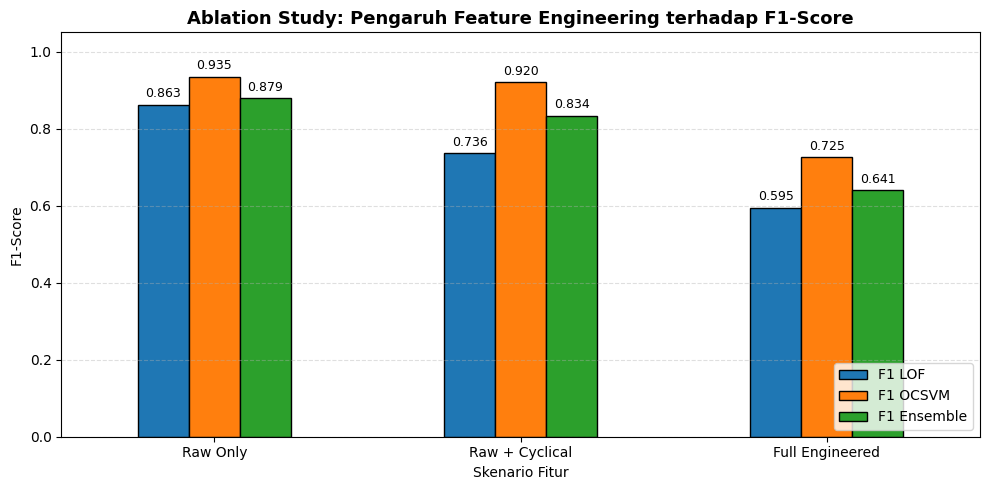

In [36]:
# Visualisasi ablation study sebagai grouped bar chart
ablation_plot = ablation_df.set_index('Skenario')[['F1 LOF', 'F1 OCSVM', 'F1 Ensemble']]

ax = ablation_plot.plot(kind='bar', figsize=(10, 5), edgecolor='black',
                        color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Ablation Study: Pengaruh Feature Engineering terhadap F1-Score",
          fontweight='bold', fontsize=13)
plt.ylabel("F1-Score")
plt.xlabel("Skenario Fitur")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

### Step 13.A - Interpretasi Ablation Study

Tabel dan grafik di atas memungkinkan diskusi pada laporan skripsi:
- Apakah penambahan **cyclical encoding** memberikan peningkatan F1-Score? (mengindikasikan model belajar pola musiman)
- Apakah penambahan **fitur turunan deret waktu** (Diff, Rolling Mean, Rolling Std) memberikan peningkatan signifikan? (mengindikasikan pentingnya konteks temporal)
- Apakah ensemble tetap superior pada semua skenario, atau hanya pada skenario tertentu?

Interpretasi konkretnya menyesuaikan angka yang dihasilkan saat notebook dijalankan.

## Step 14 - Kesimpulan

1. **Pipeline lengkap berhasil dibangun**: mulai dari pembersihan data, feature engineering deret waktu, scaling, injeksi anomali sintetik (univariat & multivariat), hingga evaluasi model unsupervised.
2. **LOF dan OCSVM** dievaluasi secara objektif menggunakan ground truth sintetik, lalu dituning melalui grid search pada validation set 2021.
3. **Ensemble heterogen** (AND-vote) berhasil meningkatkan precision dengan trade-off recall, cocok untuk skenario di mana False Positive harus ditekan.
4. **Ablation study** memberikan bukti empiris kontribusi feature engineering terhadap kinerja model deteksi anomali.

Saran pengembangan lanjutan untuk skripsi:
- Eksplorasi model lain seperti **Isolation Forest** atau **Autoencoder LSTM**.
- Tuning ambang skor (threshold tuning) berbasis ROC/PR curve, bukan hanya parameter model.
- Validasi pada dataset sungai lain untuk menguji generalisasi.